<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercicesSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1 This problem involves hyperplanes in two dimensions

## (a) Sketch the hyperplane 1 + 3X1 − X2 = 0. Indicate the set of points for which 1 + 3X1 − X2 > 0, as well as the set of points for which 1 + 3X1 − X2 < 0.

In [ ]:
range1 = np.linspace(-5, 5, 100)
range2= np.linspace(-2, 2, 100)

xx, yy = np.meshgrid(range1, range2)
x_grid = np.c_[xx.ravel(), yy.ravel()]

betas = np.array([3, -1])
b0 = 1

z = np.dot(x_grid, betas) + b0
z = z.reshape(xx.shape)

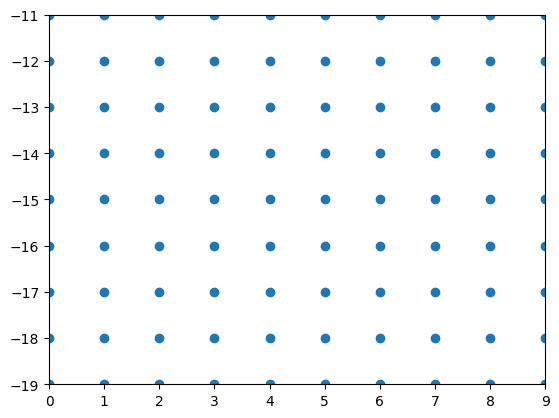

In [ ]:
r1 = np.arange(10)
r2 = np.arange(-11, -20, -1)

mesh = np.meshgrid(r1, r2)
grid= np.c_[mesh[0].ravel(), mesh[1].ravel()]
val_z = np.dot(grid, betas) + b0
val_z = val_z.reshape(mesh[0].shape)
plt.contour(mesh[0], mesh[1], val_z, levels=[0]);
plt.scatter(grid[:, 0], grid[:, 1])

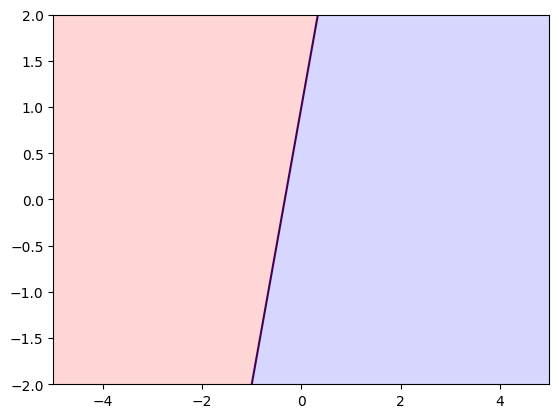

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)
plt.contour(xx, yy, z, levels=[0])

plt.show()

## (b) On the same plot, sketch the hyperplane −2 + X1 + 2X2 = 0. Indicate the set of points for which −2 + X1 + 2X2 > 0, as well as the set of points for which −2 + X1 + 2X2 < 0

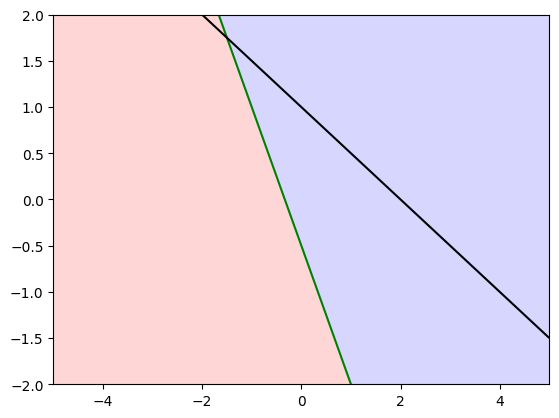

In [ ]:
new_betas = np.array([1, 2])
new_b0 = -2

new_z = np.dot(x_grid, new_betas) + new_b0
new_z = new_z.reshape(xx.shape)

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)

plt.contour(xx, yy, z, levels=[0], colors="green")
plt.contour(xx, yy, new_z, levels=[0], colors="black")


plt.show()

# 2.  We have seen that in p = 2 dimensions, a linear decision boundary takes  the form β0+β1X1+β2X2 = 0. We now investigate a non-linear decision boundary

## (a) Sketch the curve (1 + X1)^2 + (2 − X2)^2 = 4.

In [ ]:
# definamos el grid de vectores
x1 = np.linspace(-10, 10, 1000)
x2 = np.linspace(-10, 10, 1000)

xx, yy = np.meshgrid(x1, x2)
grid = np.c_[xx.ravel(), yy.ravel()]

z = (1 + grid[:, 0])**2 + (2 - grid[:, 1])**2 - 4
z = z.reshape(xx.shape)


## (b) On your sketch, indicate the set of points for which
 (1 + X1)2 + (2 − X2)2 > 4,
as well as the set of points for which
(1 + X1)2 + (2 − X2)2 ≤ 4.

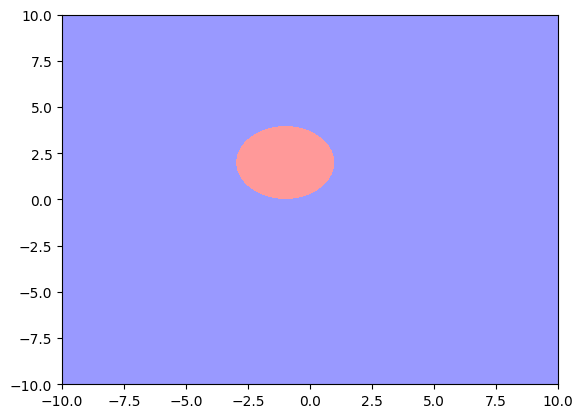

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])

## (c) Suppose that a classifier assigns an observation to the blue class if (1 + X1)2 + (2 − X2)2 > 4 and to the red class otherwise. To what class is the observation (0, 0) classified? (−1, 1)? (2, 2)? (3, 8)?

In [ ]:
obs = np.array([[0,0], [-1, 1], [2, 2], [3, 8]])
obs

array([[ 0,  0],
       [-1,  1],
       [ 2,  2],
       [ 3,  8]])

In [ ]:
zz = (1 + obs[:, 0]) ** 2 + (2 - obs[:, 1]) ** 2
np.where(zz > 4, "blue", "red")

array(['blue', 'red', 'blue', 'blue'], dtype='<U4')

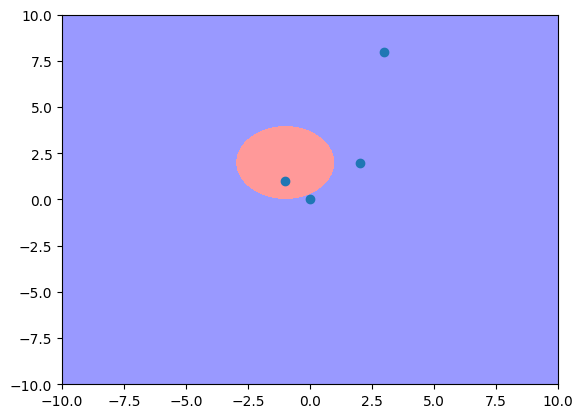

In [ ]:

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])
plt.scatter(obs[:, 0], obs[:, 1])

## (d) Argue that while the decision boundary in (c) is not linear in terms of X1 and X2, it is linear in terms of X1, X1^2, X2, and X2^2.

Esto es debido a que si expandimos la decision boundary que es no lineal, podemos apreciar que todos forman un hiperplano de forma lineal.

# 3. Here we explore the maximal margin classifier on a toy data set.


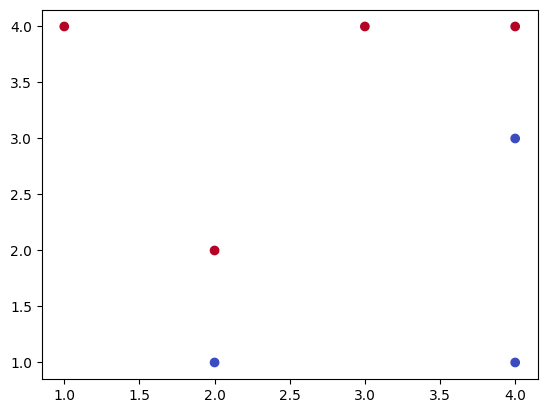

In [ ]:
obs = np.array([[3, 4],
                [2, 2],
                [4,4],
                [1, 4],
                [2,1],
                [4,3],
                [4,1]])
yy = [1,1,1,1,0,0,0]
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)

## (b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane (of the form (9.1))

In [ ]:
pendiente = (3.5 - 1.5) / (4 - 2)
pendiente

1.0

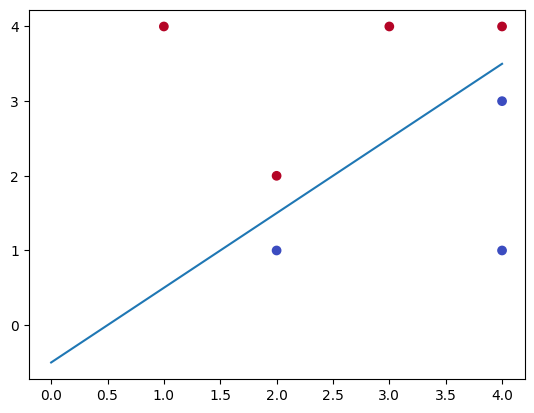

In [ ]:
x = np.arange(0, 5)
y = pendiente * x - 0.5
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)

Entonces la ecuacion del hiperplano seria:
$$-.5 + X_1 - X_2=0$$

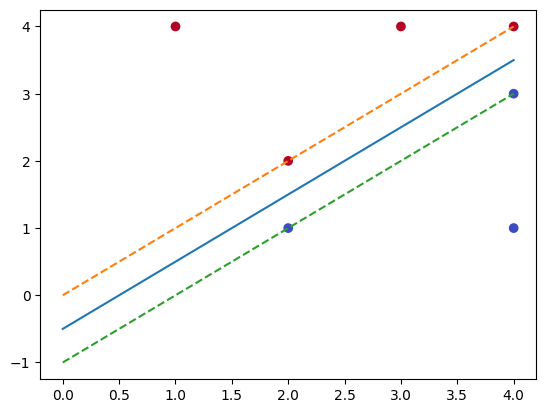

In [ ]:

plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)
plt.plot(x, y + .5,  linestyle="--")
plt.plot(x, y -.5, linestyle="--")

4